<a href="https://colab.research.google.com/github/SithilSemitha/dengue-identification-model/blob/main/Denguetest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('final.csv')

print("--- Dataset Overview ---")
print(df.info())
print("\n--- First 5 Rows ---")
print(df.head())

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 602 entries, 0 to 601
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   serial            602 non-null    int64  
 1   tempmax           602 non-null    float64
 2   tempmin           602 non-null    float64
 3   temp              602 non-null    float64
 4   feelslikemax      602 non-null    float64
 5   feelslikemin      602 non-null    float64
 6   feelslike         602 non-null    float64
 7   dew               602 non-null    float64
 8   humidity          602 non-null    float64
 9   precip            602 non-null    float64
 10  precipprob        602 non-null    float64
 11  precipcover       602 non-null    float64
 12  snow              602 non-null    float64
 13  snowdepth         602 non-null    float64
 14  windspeed         602 non-null    float64
 15  winddir           602 non-null    float64
 16  sealevelpressure  6

In [ ]:
#Feature Selection
target_col = 'cases'

if 'serial' in df.columns:
    df = df.drop(columns=['serial'])

# Drop the 'labels' column as it contains non-numeric data
if 'labels' in df.columns:
    df = df.drop(columns=['labels'])

X = df.drop(columns=[target_col])
y = df[target_col]

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (Helps keep the numeric features uniform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features being used: {list(X.columns)}")
print(f"Training set: {X_train.shape[0]} rows | Testing set: {X_test.shape[0]} rows")

Features being used: ['tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover', 'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'conditions', 'stations']
Training set: 481 rows | Testing set: 121 rows


In [ ]:
#Model Training
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)
print("Dengue Prediction Model trained successfully!")

Dengue Prediction Model trained successfully!


--- Model Performance Metrics ---
Mean Absolute Error (MAE): 3266.08 cases
Root Mean Squared Error (RMSE): 4467.88 cases
R-squared Score (R2): 0.5197 (Closer to 1.0 is better)


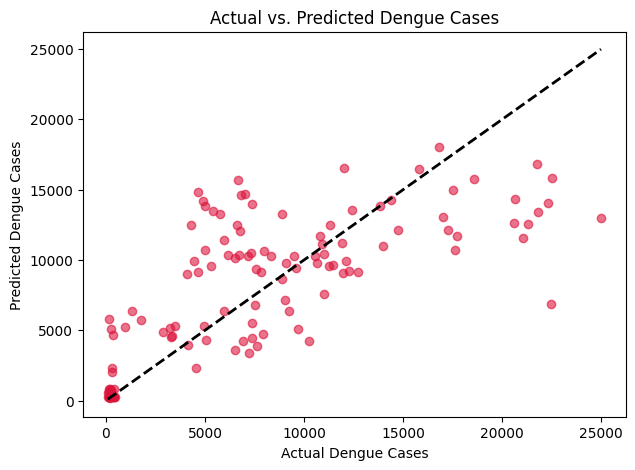

/tmp/ipykernel_10018/2238886242.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


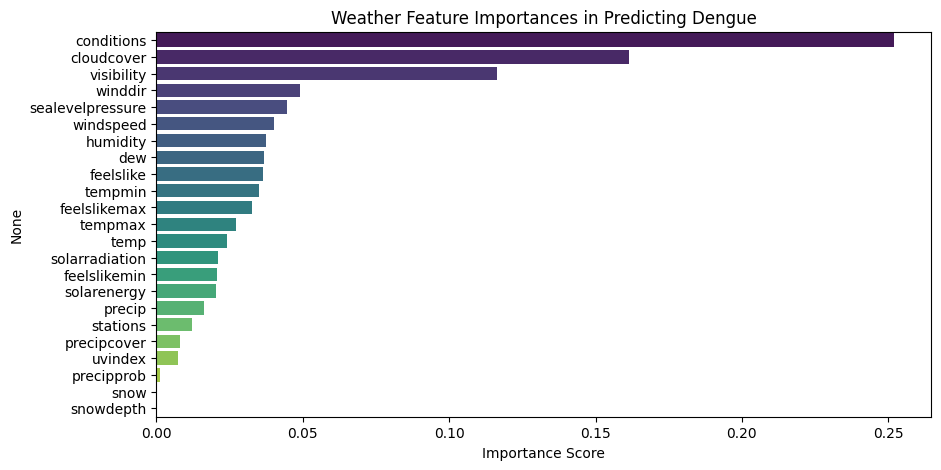

In [ ]:
# ==========================================
# CELL 4: Evaluation & Performance Visualization
# ==========================================
# Predict on test data
y_pred = model.predict(X_test_scaled)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} cases")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} cases")
print(f"R-squared Score (R2): {r2:.4f} (Closer to 1.0 is better)")

# Plot Actual vs Predicted values
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='crimson')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Dengue Cases')
plt.ylabel('Predicted Dengue Cases')
plt.title('Actual vs. Predicted Dengue Cases')
plt.show()

# Plot Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Weather Feature Importances in Predicting Dengue")
plt.xlabel("Importance Score")
plt.show()


In [ ]:
# ==========================================
# CELL 5: Test Inference on Custom Weather Data
# ==========================================
# Create a dictionary matching the exact features in your X dataframe
# Example values using standard weather metrics (tempmax, tempmin, temp, feelslike, etc.)
custom_weather_data = {col: [X[col].mean()] for col in X.columns}

# You can manually adjust specific fields to test scenarios:
# custom_weather_data['tempmax'] = [35.0]
# custom_weather_data['humidity'] = [85.0]

custom_df = pd.DataFrame(custom_weather_data)

# Scale and predict
custom_scaled = scaler.transform(custom_df)
predicted_cases = model.predict(custom_scaled)[0]

print(f"Predicted number of expected Dengue cases for this weather profile: **{predicted_cases:.1f} cases**")

Predicted number of expected Dengue cases for this weather profile: **9678.0 cases**
